<a href="https://colab.research.google.com/github/epmbanten/Tugas-AI-602225073-Dody-Suhendra/blob/main/Tugas3_AI_DodySuhendra_6022251073.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

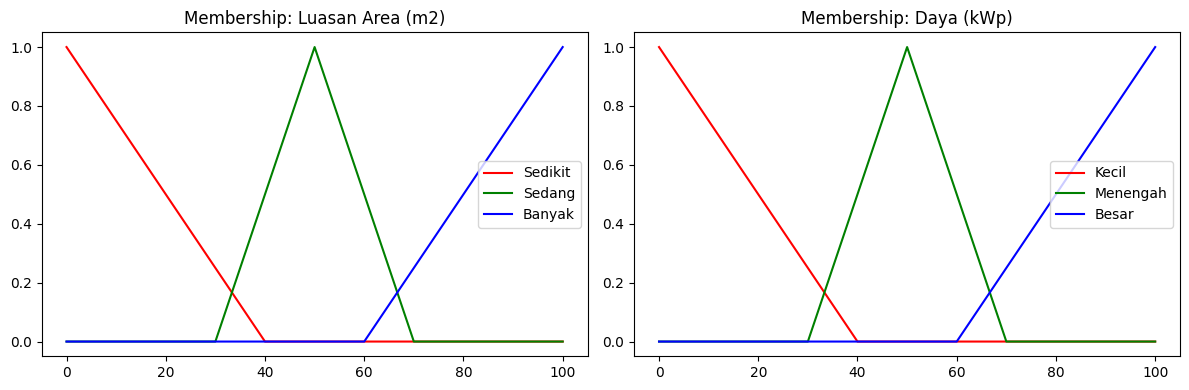

-----------------------------------
INPUT:
Luasan Area : 70 m2
Daya PV     : 80 kWp
-----------------------------------
HASIL DEFUZZIFIKASI
Estimasi Harga Paket Platinum: Rp 100.00 Juta
-----------------------------------


In [27]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. DEFINISI FUNGSI KEANGGOTAAN (MEMBERSHIP)
# ==========================================
def trimf(x, abc):
    """Fungsi Triangular Membership"""
    a, b, c = abc
    res = np.zeros_like(x, dtype=float)
    if a != b:
        idx = np.logical_and(a < x, x <= b)
        res[idx] = (x[idx] - a) / (b - a)
    else:
        res[x == a] = 1.0

    if b != c:
        idx = np.logical_and(b < x, x < c)
        res[idx] = (c - x[idx]) / (c - b)
    else:
        res[x == b] = 1.0

    res[x == b] = 1.0
    return np.maximum(res, 0)

# Semesta Pembicaraan
x_area = np.linspace(0, 100, 101)  # Luasan 0-100 m2
x_daya = np.linspace(0, 100, 101)   # Daya 0-100 kWp

# Himpunan Fuzzy Input 1: Luasan Area
area_sedikit = trimf(x_area, [0, 0, 40])
area_sedang   = trimf(x_area, [30, 50, 70])
area_banyak   = trimf(x_area, [60, 100, 100])

# Himpunan Fuzzy Input 2: Daya
daya_kecil    = trimf(x_daya, [0, 0, 40])
daya_menengah = trimf(x_daya, [30, 50, 70])
daya_besar    = trimf(x_daya, [60, 100, 100])

# Output Singleton (Sugeno Orde-0) - Dalam Juta Rupiah
out_basic    = 25
out_premium  = 50
out_platinum = 100

# ==========================================
# 2. VISUALISASI FUNGSI KEANGGOTAAN
# ==========================================
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(x_area, area_sedikit, 'r', label='Sedikit')
plt.plot(x_area, area_sedang, 'g', label='Sedang')
plt.plot(x_area, area_banyak, 'b', label='Banyak')
plt.title('Membership: Luasan Area (m2)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(x_daya, daya_kecil, 'r', label='Kecil')
plt.plot(x_daya, daya_menengah, 'g', label='Menengah')
plt.plot(x_daya, daya_besar, 'b', label='Besar')
plt.title('Membership: Daya (kWp)')
plt.legend()

plt.tight_layout()
plt.show()

# ==========================================
# 3. MESIN INFERENSI (SUGENO)
# ==========================================
def hitung_fis(in_area, in_daya):
    # Fuzzifikasi
    μ_area_sedikit = np.interp(in_area, x_area, area_sedikit)
    μ_area_sedang  = np.interp(in_area, x_area, area_sedang)
    μ_area_banyak  = np.interp(in_area, x_area, area_banyak)

    μ_daya_kecil    = np.interp(in_daya, x_daya, daya_kecil)
    μ_daya_menengah = np.interp(in_daya, x_daya, daya_menengah)
    μ_daya_besar    = np.interp(in_daya, x_daya, daya_besar)

    # Rule Base & Firing Strength (w) menggunakan MIN
    # R1: IF Daya Kecil AND Area Sedikit THEN Basic
    w1 = min(μ_daya_kecil, μ_area_sedikit)
    # R2: IF Daya Kecil AND Area Sedang THEN Basic
    w2 = min(μ_daya_kecil, μ_area_sedang)
    # R3: IF Daya Kecil AND Area Banyak THEN Premium
    w3 = min(μ_daya_kecil, μ_area_banyak)
    # R4: IF Daya Menengah AND Area Sedikit THEN Premium
    w4 = min(μ_daya_menengah, μ_area_sedikit)
    # R5: IF Daya Menengah AND Area Sedang THEN Premium
    w5 = min(μ_daya_menengah, μ_area_sedang)
    # R6: IF Daya Menengah AND Area Banyak THEN Premium
    w6 = min(μ_daya_menengah, μ_area_banyak)
    # R7: IF Daya Besar AND Area Sedikit THEN Premium
    w7 = min(μ_daya_besar, μ_area_sedikit)
    # R8: IF Daya Besar AND Area Sedang THEN Platinum
    w8 = min(μ_daya_besar, μ_area_sedang)
    # R9: IF Daya Besar AND Area Banyak THEN Platinum
    w9 = min(μ_daya_besar, μ_area_banyak)

    # Defuzzifikasi (Weighted Average)
    numerator = (w1*out_basic + w2*out_basic + w3*out_premium +
                 w4*out_premium + w5*out_premium + w6*out_premium +
                 w7*out_premium + w8*out_platinum + w9*out_platinum)

    denominator = w1 + w2 + w3 + w4 + w5 + w6 + w7 + w8 + w9

    if denominator == 0:
        return 0

    return numerator / denominator

# ==========================================
# 4. TESTING & SIMULASI
# ==========================================
input_user_area = 70 # Contoh input luasan
input_user_daya = 80  # Contoh input daya besar

harga_hasil = hitung_fis(input_user_area, input_user_daya)

# Menentukan PAKET berdasarkan harga_hasil dengan mencari singleton output terdekat.
output_options_values = [out_basic, out_premium, out_platinum]
output_options_names = {out_basic: "Basic", out_premium: "Premium", out_platinum: "Platinum"}

# Temukan opsi keluaran terdekat
closest_output_value = min(output_options_values, key=lambda x: abs(x - harga_hasil))
PAKET = output_options_names[closest_output_value]

print("-" * 35)
print(f"INPUT:")
print(f"Luasan Area : {input_user_area} m2")
print(f"Daya PV     : {input_user_daya} kWp")
print("-" * 35)
print(f"HASIL DEFUZZIFIKASI")
print(f"Estimasi Harga Paket {PAKET}: Rp {harga_hasil:.2f} Juta")
print("-" * 35)